<a href="https://colab.research.google.com/github/Tolureis/CMPE-460-Deep-Learning/blob/main/Adam_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gradient Descent With Fixed Step (200 step)_______________________


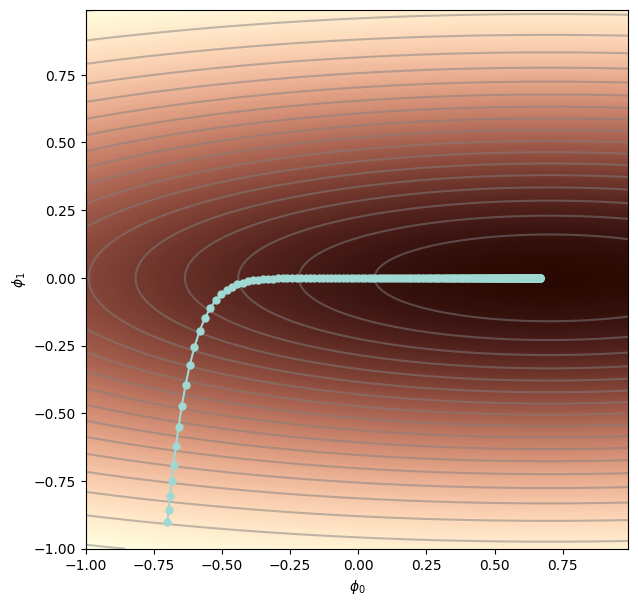

Gradient Descent With Fixed Step (60 step)_______________________


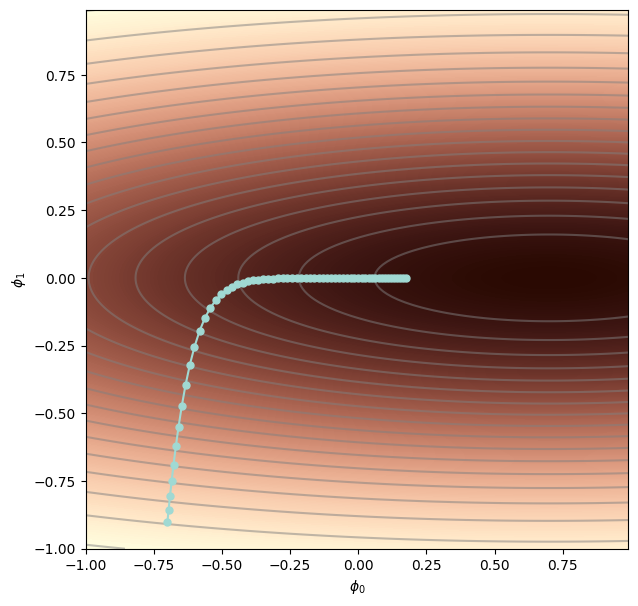

Normalized gradients (AdaGrad/RMSProp) (60 step)_______________________


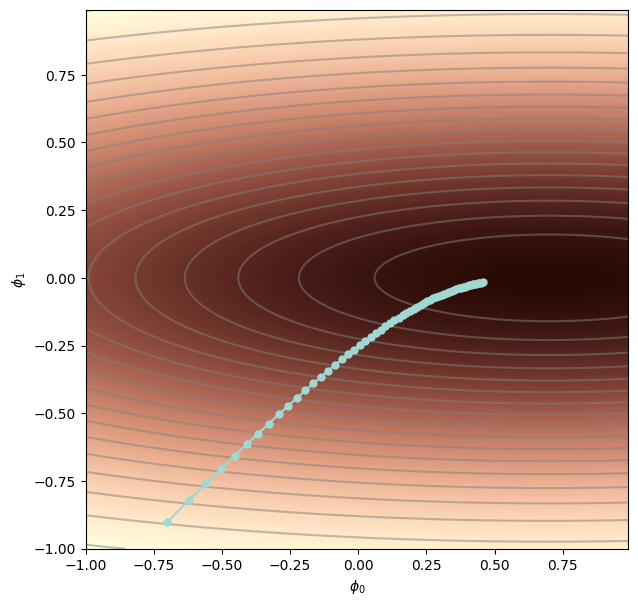

ADAM Optimizer (60 step)_______________________


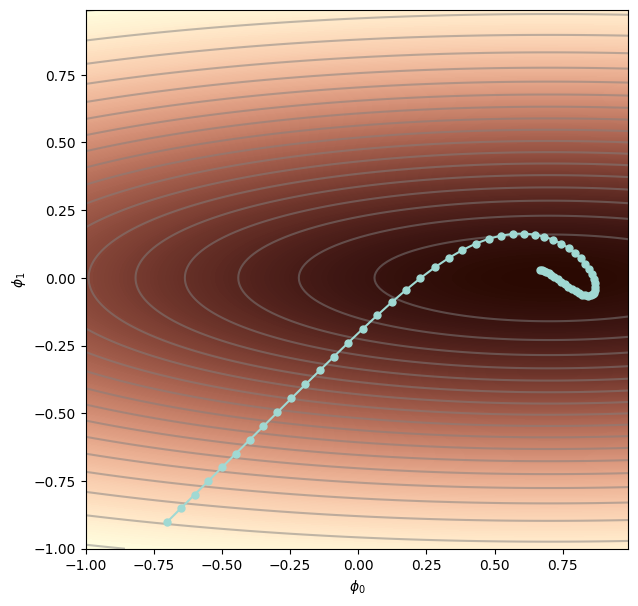

In [ ]:
# -*- coding: utf-8 -*-
# ------------------------------------------------------------
# Gradient Descent, Normalized Gradient, and Adam Algorithm Demo
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ------------------------------------------------------------
# LOSS FUNCTION
# ------------------------------------------------------------
def loss(phi0, phi1):
    height = np.exp(-0.5 * (phi1 * phi1) * 4.0)
    height = height * np.exp(-0.5 * (phi0 - 0.7) * (phi0 - 0.7) / 4.0)
    return 1.0 - height

# ------------------------------------------------------------
# GRADIENT ESTIMATION (Finite Differences)
# ------------------------------------------------------------
def get_loss_gradient(phi0, phi1):
    delta_phi = 1e-5
    gradient = np.zeros((2, 1))
    gradient[0] = (loss(phi0 + delta_phi/2.0, phi1) - loss(phi0 - delta_phi/2.0, phi1)) / delta_phi
    gradient[1] = (loss(phi0, phi1 + delta_phi/2.0) - loss(phi0, phi1 - delta_phi/2.0)) / delta_phi
    return gradient[:, 0]

# ------------------------------------------------------------
# LOSS FUNCTION FOR VISUALIZATION
# ------------------------------------------------------------
def get_loss_function_for_plot():
    grid_values = np.arange(-1.0, 1.0, 0.01)
    phi0mesh, phi1mesh = np.meshgrid(grid_values, grid_values)
    loss_function = np.zeros((grid_values.size, grid_values.size))
    for idphi0, phi0 in enumerate(grid_values):
        for idphi1, phi1 in enumerate(grid_values):
            loss_function[idphi0, idphi1] = loss(phi1, phi0)
    return loss_function, phi0mesh, phi1mesh

# ------------------------------------------------------------
# CUSTOM COLORMAP
# ------------------------------------------------------------
my_colormap_vals_hex = (
    '2a0902','2b0a03','2c0b04','2d0c05','2e0c06','2f0d07','300d08','310e09','320f0a','330f0b','34100b','35110c',
    '36110d','37120e','38120f','39130f','3a1410','3b1411','3c1511','3d1612','3e1613','3f1713','401714','411814',
    '421915','431915','451a16','461b16','471b17','481c17','491d18','4a1d18','4b1e19','4c1f19','4d1f1a','4e201b',
    '50211b','51211c','52221c','53231d','54231d','55241e','56251e','57261f','58261f','592720','5b2821','5c2821',
    '5d2922','5e2a22','5f2b23','602b23','612c24','622d25','632e25','652e26','662f26','673027','683027','693128',
    '6a3229','6b3329','6c342a','6d342a','6f352b','70362c','71372c','72372d','73382e','74392e','753a2f','763a2f',
    '773b30','783c31','7a3d31','7b3e32','7c3e33','7d3f33','7e4034','7f4134','804235','814236','824336','834437',
    '854538','864638','874739','88473a','89483a','8a493b','8b4a3c','8c4b3c','8d4c3d','8e4c3e','8f4d3f','904e3f',
    '924f40','935041','945141','955242','965343','975343','985444','995545','9a5646','9b5746','9c5847','9d5948',
    '9e5a49','9f5a49','a05b4a','a15c4b','a35d4b','a45e4c','a55f4d','a6604e','a7614e','a8624f','a96350','aa6451',
    'ab6552','ac6552','ad6653','ae6754','af6855','b06955','b16a56','b26b57','b36c58','b46d59','b56e59','b66f5a',
    'b7705b','b8715c','b9725d','ba735d','bb745e','bc755f','bd7660','be7761','bf7862','c07962','c17a63','c27b64',
    'c27c65','c37d66','c47e67','c57f68','c68068','c78169','c8826a','c9836b','ca846c','cb856d','cc866e','cd876f',
    'ce886f','ce8970','cf8a71','d08b72','d18c73','d28d74','d38e75','d48f76','d59077','d59178','d69279','d7937a',
    'd8957b','d9967b','da977c','da987d','db997e','dc9a7f','dd9b80','de9c81','de9d82','df9e83','e09f84','e1a185',
    'e2a286','e2a387','e3a488','e4a589','e5a68a','e5a78b','e6a88c','e7aa8d','e7ab8e','e8ac8f','e9ad90','eaae91',
    'eaaf92','ebb093','ecb295','ecb396','edb497','eeb598','eeb699','efb79a','efb99b','f0ba9c','f1bb9d','f1bc9e',
    'f2bd9f','f2bfa1','f3c0a2','f3c1a3','f4c2a4','f5c3a5','f5c5a6','f6c6a7','f6c7a8','f7c8aa','f7c9ab','f8cbac',
    'f8ccad','f8cdae','f9ceb0','f9d0b1','fad1b2','fad2b3','fbd3b4','fbd5b6','fbd6b7','fcd7b8','fcd8b9','fcdaba',
    'fddbbc','fddcbd','fddebe','fddfbf','fee0c1','fee1c2','fee3c3','fee4c5','ffe5c6','ffe7c7','ffe8c9','ffe9ca',
    'ffebcb','ffeccd','ffedce','ffefcf','fff0d1','fff2d2','fff3d3','fff4d5','fff6d6','fff7d8','fff8d9','fffada',
    'fffbdc','fffcdd','fffedf','ffffe0'
)
my_colormap_vals_dec = np.array([int(element, base=16) for element in my_colormap_vals_hex])
r = np.floor(my_colormap_vals_dec / (256*256))
g = np.floor((my_colormap_vals_dec - r*256*256) / 256)
b = np.floor(my_colormap_vals_dec - r*256*256 - g*256)
my_colormap_vals = np.vstack((r, g, b)).T / 255.0
my_colormap = ListedColormap(my_colormap_vals)

# ------------------------------------------------------------
# DRAW FUNCTION
# ------------------------------------------------------------
def draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, opt_path):
    fig = plt.figure()
    ax = plt.axes()
    fig.set_size_inches(7, 7)
    ax.contourf(phi0mesh, phi1mesh, loss_function, 256, cmap=my_colormap)
    ax.contour(phi0mesh, phi1mesh, loss_function, 20, colors=['#80808080'])
    ax.plot(opt_path[0, :], opt_path[1, :], '-', color='#a0d9d3ff')
    ax.plot(opt_path[0, :], opt_path[1, :], '.', color='#a0d9d3ff', markersize=10)
    ax.set_xlabel(r"$\phi_{0}$")
    ax.set_ylabel(r"$\phi_{1}$")
    plt.show()

# ------------------------------------------------------------
# FIXED STEP GRADIENT DESCENT
# ------------------------------------------------------------
def grad_descent(start_posn, n_steps, alpha):
    grad_path = np.zeros((2, n_steps + 1))
    grad_path[:, 0] = start_posn[:, 0]
    for c_step in range(n_steps):
        this_grad = get_loss_gradient(grad_path[0, c_step], grad_path[1, c_step])
        grad_path[:, c_step + 1] = grad_path[:, c_step] - alpha * this_grad
    return grad_path

# ------------------------------------------------------------
# NORMALIZED GRADIENTS (ADAGRAD STYLE)
# ------------------------------------------------------------
def normalized_gradients(start_posn, n_steps, alpha, epsilon=1e-20):
    grad_path = np.zeros((2, n_steps + 1))
    grad_path[:, 0] = start_posn[:, 0]
    v = np.zeros(2)
    for c_step in range(n_steps):
        # Gradient
        m = get_loss_gradient(grad_path[0, c_step], grad_path[1, c_step])
        # Squared gradient accumulation
        v = v + np.power(m, 2)
        # Update rule (Eq. 6.14)
        grad_path[:, c_step + 1] = grad_path[:, c_step] - alpha * (m / (np.sqrt(v) + epsilon))
    return grad_path

# ------------------------------------------------------------
# ADAM OPTIMIZER
# ------------------------------------------------------------
def adam(start_posn, n_steps, alpha, beta=0.9, gamma=0.99, epsilon=1e-20):
    grad_path = np.zeros((2, n_steps + 1))
    grad_path[:, 0] = start_posn[:, 0]
    m = np.zeros(2)
    v = np.zeros(2)
    for c_step in range(n_steps):
        grad = get_loss_gradient(grad_path[0, c_step], grad_path[1, c_step])
        # Momentum-based gradient estimate (Eq. 6.15 - line 1)
        m = beta * m + (1 - beta) * grad
        # Momentum-based squared gradient estimate (Eq. 6.15 - line 2)
        v = gamma * v + (1 - gamma) * np.power(grad, 2)
        # Bias correction (Eq. 6.16)
        m_tilde = m / (1 - np.power(beta, c_step + 1))
        v_tilde = v / (1 - np.power(gamma, c_step + 1))
        # Update rule (Eq. 6.17)
        grad_path[:, c_step + 1] = grad_path[:, c_step] - alpha * (m_tilde / (np.sqrt(v_tilde) + epsilon))
    return grad_path

# ------------------------------------------------------------
# RUN AND PLOT RESULTS
# ------------------------------------------------------------
loss_function, phi0mesh, phi1mesh = get_loss_function_for_plot()

start_posn = np.array([[-0.7], [-0.9]])

# Fixed step gradient descent
print("Gradient Descent With Fixed Step (200 step)_______________________")

grad_path1 = grad_descent(start_posn, n_steps=200, alpha=0.08)
draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, grad_path1)

print("Gradient Descent With Fixed Step (60 step)_______________________")

grad_path1 = grad_descent(start_posn, n_steps=60, alpha=0.08)
draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, grad_path1)

print("Normalized gradients (AdaGrad/RMSProp) (60 step)_______________________")
# Normalized gradients
grad_path3 = normalized_gradients(start_posn, n_steps=60, alpha=0.08)
draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, grad_path3)

print("ADAM Optimizer (60 step)_______________________")

# Adam optimizer
grad_path4 = adam(start_posn, n_steps=60, alpha=0.05)
draw_function(phi0mesh, phi1mesh, loss_function, my_colormap, grad_path4)
